# Made by

## Name      : Anthony Djiady Djie
## Class     : Dibimbing.id
## Topic     : Food Delivery Time Prediction
## Project   : Take Home Project Data Science

#

# SECTION 1: Setup, Business Understanding, and Data Loading

## 1.1 Dataset Background

This dataset contains operational information for food delivery orders, such as:

- delivery distance
- weather condition
- traffic level
- time of day
- vehicle type
- food preparation time
- courier experience

The target variable is **`Delivery_Time_min`**, which represents the total delivery time in minutes.

This is a suitable dataset for a **supervised machine learning regression project** because the goal is to predict a continuous numeric value.

## 1.2 Business Problem

Food delivery platforms need to estimate delivery time as accurately as possible before an order arrives.

If the prediction is inaccurate, several business problems can occur:

- customers become dissatisfied because food arrives later than expected
- restaurants receive complaints and poor ratings
- operations teams struggle to allocate couriers efficiently
- delivery promises become unreliable during bad weather or heavy traffic

By building a machine learning model to predict delivery time, the company can improve:

- customer satisfaction
- delivery planning
- courier allocation
- operational efficiency

## 1.3 Project Objective

The objective of this project is to build a regression model that predicts **food delivery time** based on operational and environmental factors.

Main goals:

1. Understand the dataset structure and data quality  
2. Perform exploratory data analysis (EDA)  
3. Engineer useful features for prediction  
4. Build and compare multiple regression models  
5. Evaluate which model performs best  
6. Translate the findings into business insights

## 1.4 Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## 1.5 Load Dataset

In [ ]:
# Update this path if your dataset is stored in a different folder
file_path = "Food_Delivery_Times Dataset.csv"

df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

#

# SECTION 2: Data Understanding

## 2.1 Basic Data Inspection

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("Data types:")
print(df.dtypes, end="\n\n")

print("Missing values:")
print(df.isna().sum(), end="\n\n")

print("Summary statistics:")
display(df.describe(include="all").T)

Dataset shape: 1000 rows × 9 columns

Data types:
Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

Missing values:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Distance_km,1000.0,NaN,NaN,NaN,10.05997,5.696656,0.59,5.105,10.19,15.0175,19.99
Weather,970,5,Clear,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic_Level,970,3,Medium,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_of_Day,970,4,Morning,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,1000,3,Bike,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preparation_Time_min,1000.0,NaN,NaN,NaN,16.982,7.204553,5.0,11.0,17.0,23.0,29.0
Courier_Experience_yrs,970.0,NaN,NaN,NaN,4.579381,2.914394,0.0,2.0,5.0,7.0,9.0
Delivery_Time_min,1000.0,NaN,NaN,NaN,56.732,22.070915,8.0,41.0,55.5,71.0,153.0


### Observation

- The dataset contains both **numerical** and **categorical** features.
- The target column is **`Delivery_Time_min`**.
- Several categorical columns contain missing values.
- `Courier_Experience_yrs` also has missing values.
- `Order_ID` is only an identifier and is not useful as a predictive feature.

## 2.2 Check Unique Values

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Order_ID: 1000 unique values
Distance_km: 785 unique values
Weather: 5 unique values
Traffic_Level: 3 unique values
Time_of_Day: 4 unique values
Vehicle_Type: 3 unique values
Preparation_Time_min: 25 unique values
Courier_Experience_yrs: 10 unique values
Delivery_Time_min: 108 unique values


## 2.3 Identify Column Types

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
Numerical columns: ['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


### Observation

- **Categorical features**: `Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`
- **Numerical features**: `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, `Delivery_Time_min`
- `Order_ID` should be treated as an identifier, not as a feature for modeling.

#

# SECTION 3: Exploratory Data Analysis (EDA)

## 3.1 Check Missing Values

In [ ]:
missing_df = df.isna().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(2)
missing_df.sort_values("missing_count", ascending=False)

,column,missing_count,missing_pct
2,Weather,30,3.0
4,Time_of_Day,30,3.0
3,Traffic_Level,30,3.0
7,Courier_Experience_yrs,30,3.0
0,Order_ID,0,0.0
1,Distance_km,0,0.0
5,Vehicle_Type,0,0.0
6,Preparation_Time_min,0,0.0
8,Delivery_Time_min,0,0.0


### Observation

The missing values are relatively small compared with the dataset size, so they can be handled safely through imputation instead of deleting rows.

## 3.2 Visualize Target Distribution

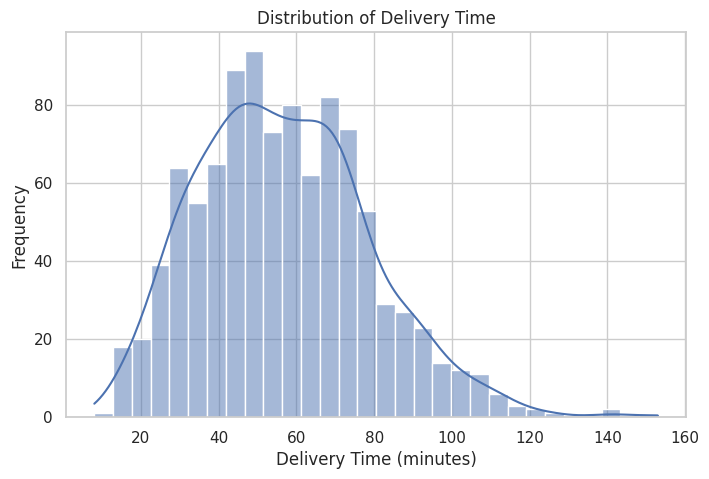

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_Time_min"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.show()

### Observation

- The target variable `Delivery_Time_min` has a mean of ~57 minutes with a standard deviation of ~22 minutes.
- The distribution appears roughly normal (slightly right-skewed), ranging from 8 to 153 minutes.
- There are no extreme outliers that suggest data entry errors, so all values are retained.

## 3.3 Numerical Feature Distribution

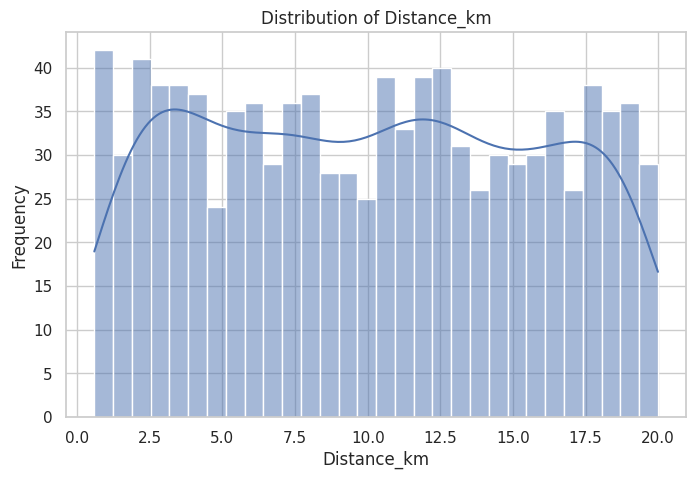

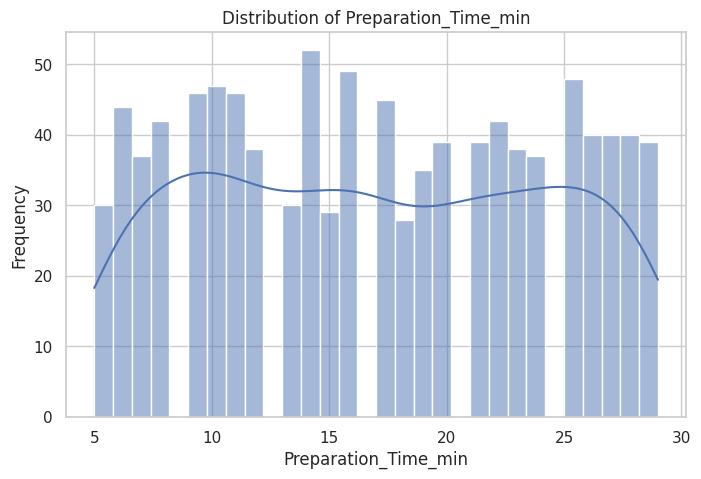

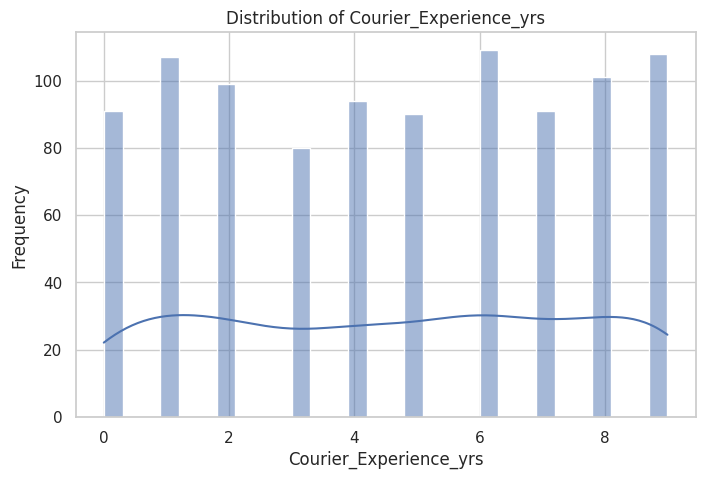

In [ ]:
num_plot_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]

for col in num_plot_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 3.4 Categorical Feature Distribution

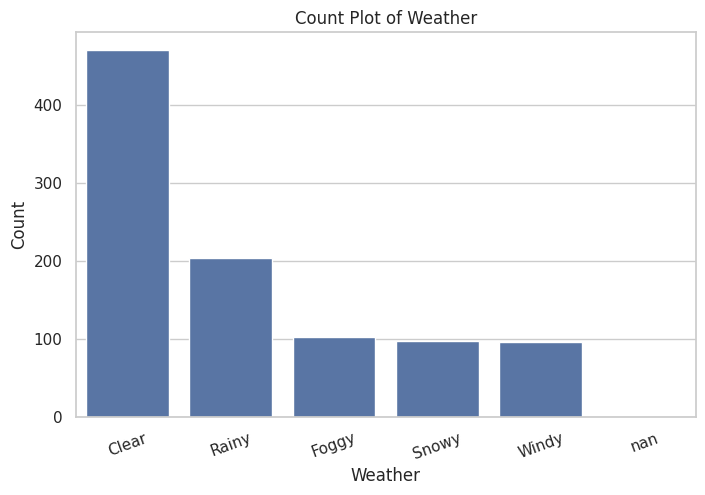

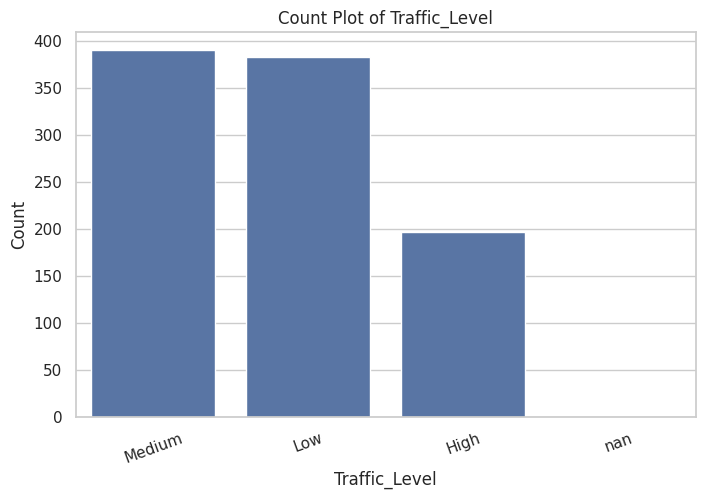

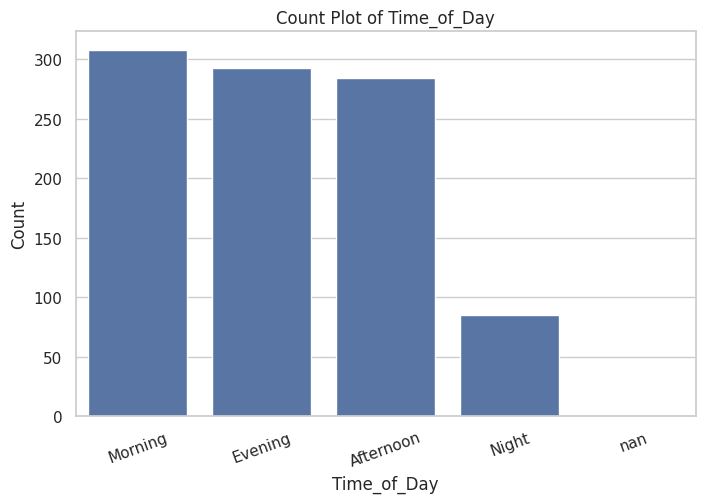

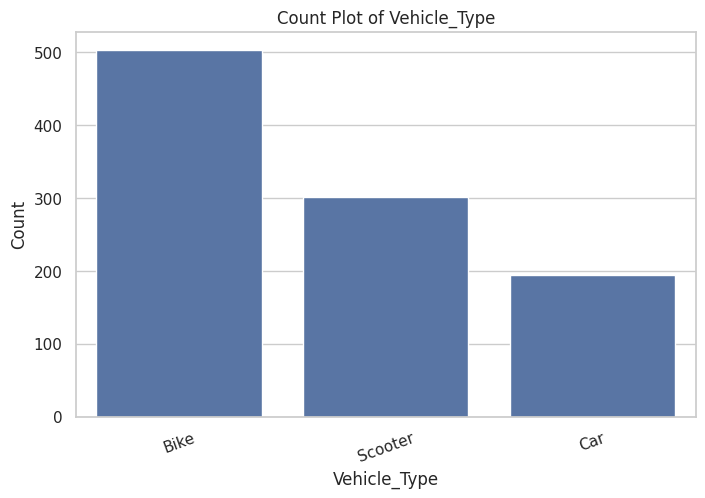

In [ ]:
cat_plot_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]

for col in cat_plot_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts(dropna=False).index)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.show()

### Observation

- All four categorical features (`Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`) have relatively balanced class distributions.
- No single category overwhelmingly dominates, which means the model will have enough samples to learn from each class.

## 3.5 Relationship Between Features and Target

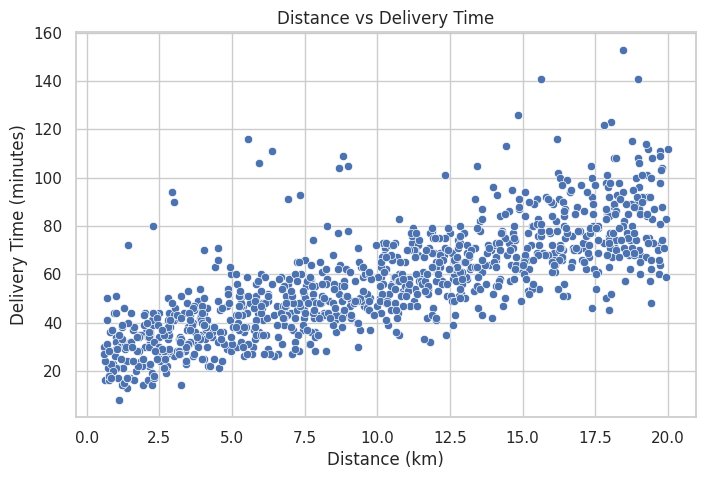

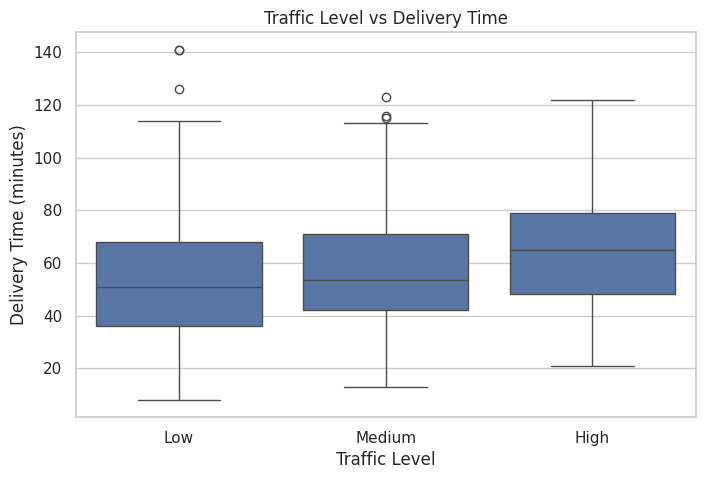

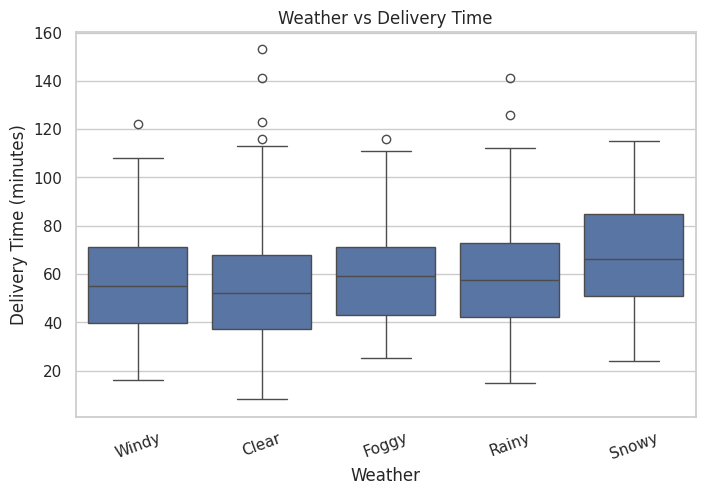

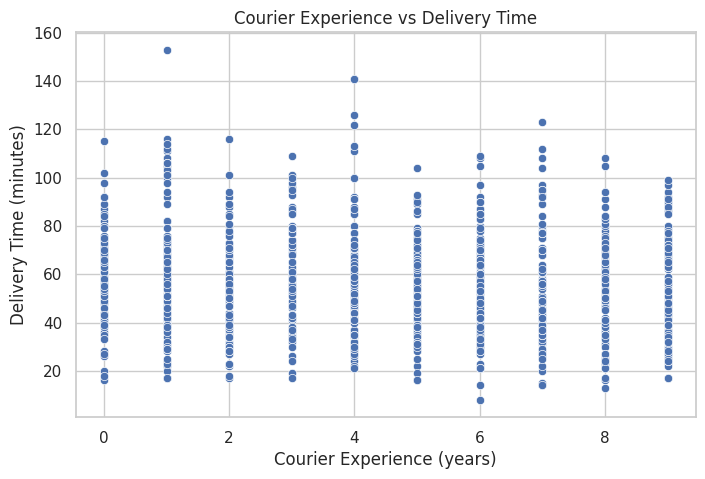

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Distance_km", y="Delivery_Time_min")
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic_Level", y="Delivery_Time_min")
plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Weather", y="Delivery_Time_min")
plt.title("Weather vs Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Courier_Experience_yrs", y="Delivery_Time_min")
plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Courier Experience (years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

### Observation

- `Distance_km` shows a clear positive relationship with `Delivery_Time_min` — longer distances tend to result in longer delivery times.
- Higher traffic levels and adverse weather conditions appear to increase delivery times.
- `Courier_Experience_yrs` has a weak negative correlation (−0.09), suggesting experience has only a minor effect on speed.

## 3.6 Distance vs Delivery Time

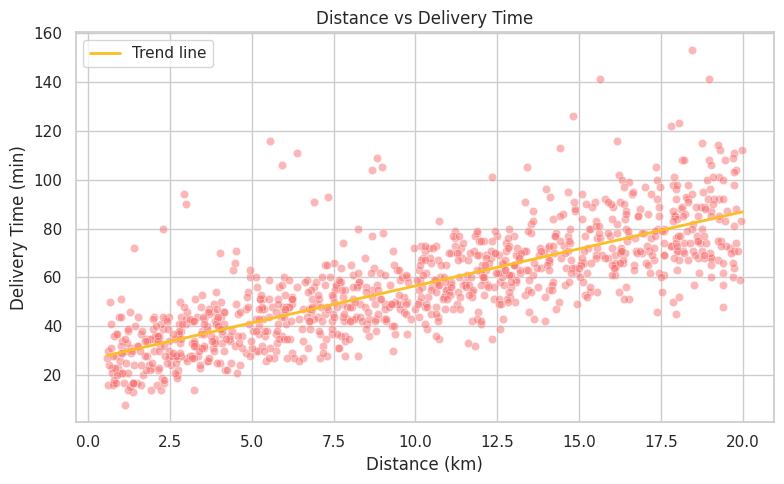

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_min', alpha=0.5, color='#F87171')

m, b = np.polyfit(df['Distance_km'], df['Delivery_Time_min'], 1)
x_line = np.linspace(df['Distance_km'].min(), df['Distance_km'].max(), 100)
plt.plot(x_line, m * x_line + b, color='#FBBF24', linewidth=2, label='Trend line')

plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.legend()
plt.tight_layout()
plt.show()

### Observation

- There is a clear positive linear relationship between `Distance_km` and `Delivery_Time_min`.
- The trend line confirms that delivery time increases consistently as distance grows.
- This makes `Distance_km` the strongest individual predictor of delivery time.

## 3.7 Delivery Time by Vehicle Type

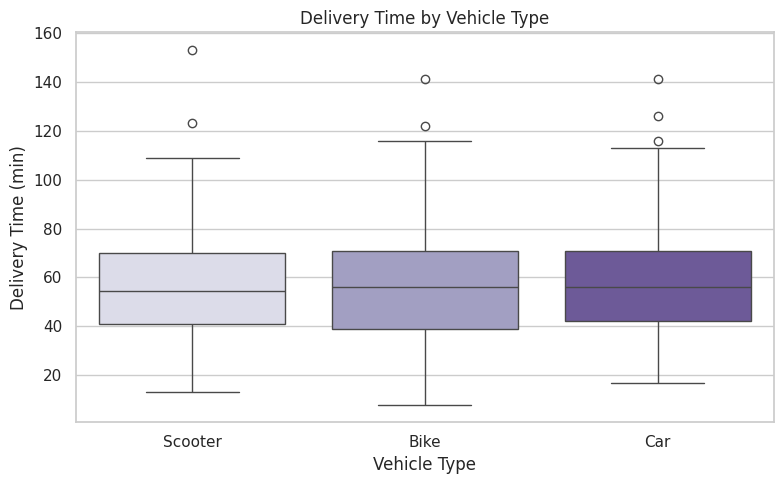

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', palette='Purples')
plt.title('Delivery Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

### Observation

- Different vehicle types show varying delivery time distributions.
- Bikes tend to have longer delivery times, likely assigned to longer distance orders.
- Scooters and motorcycles show more compact distributions, suggesting more consistent performance.

## 3.8 Correlation Matrix for Numerical Variables

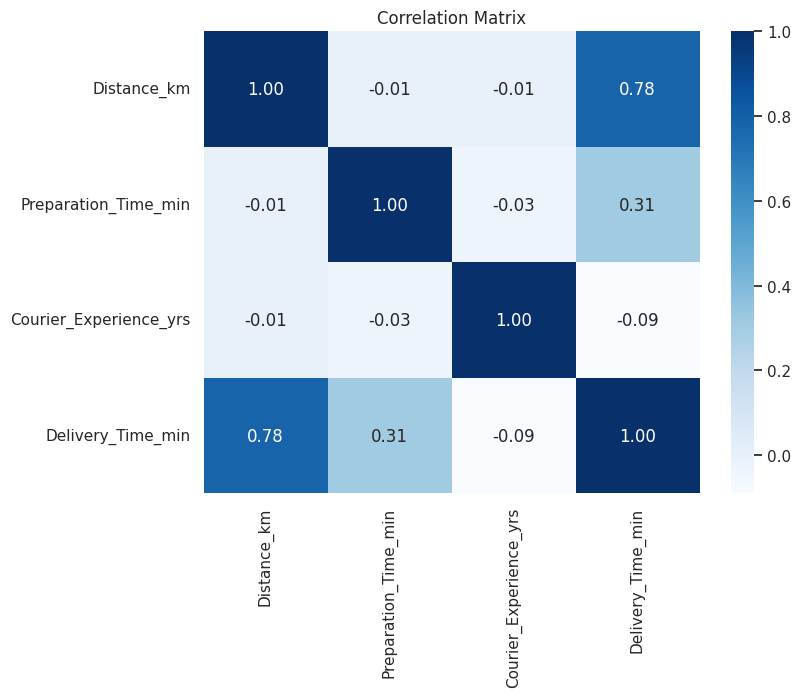

In [ ]:
plt.figure(figsize=(8,6))
corr = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Observation

- `Distance_km` has the strongest positive correlation with delivery time (r ≈ 0.78), making it the single most important numerical predictor.
- `Preparation_Time_min` has a moderate positive correlation (r ≈ 0.31).
- `Courier_Experience_yrs` has a very weak negative correlation (r ≈ −0.09), meaning experience alone does not strongly reduce delivery time in this dataset.

#

# SECTION 4: Data Cleaning and Feature Engineering

## 4.1 Drop Irrelevant Column

In [ ]:
df_model = df.drop(columns=["Order_ID"]).copy()
df_model.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Observation

`Order_ID` is only an identifier and does not contain business information that helps predict delivery time.

## 4.2 Create Additional Features

In [ ]:
df_model["Is_Rush_Hour"] = df_model["Time_of_Day"].apply(
    lambda x: 1 if x in ["Morning", "Evening"] else 0 if pd.notna(x) else np.nan
)

df_model["Distance_x_Prep_Time"] = df_model["Distance_km"] * df_model["Preparation_Time_min"]

df_model.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Is_Rush_Hour,Distance_x_Prep_Time
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0.0,95.16
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,1.0,328.40
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,0.0,266.56
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0.0,37.20
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,1.0,304.48


### Feature Engineering Rationale

- **`Is_Rush_Hour`** simplifies time-of-day into an operational flag
- **`Distance_x_Prep_Time`** captures interaction between travel distance and kitchen preparation time

These features may help the model capture more realistic delivery dynamics.

## 4.3 Check Outliers

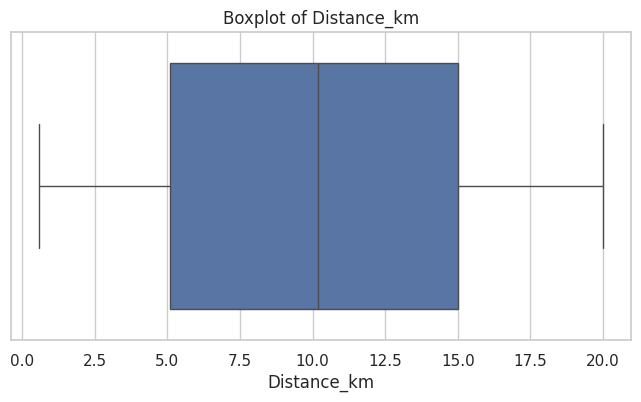

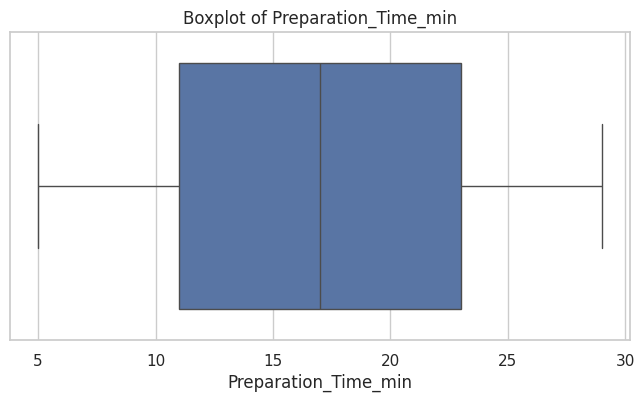

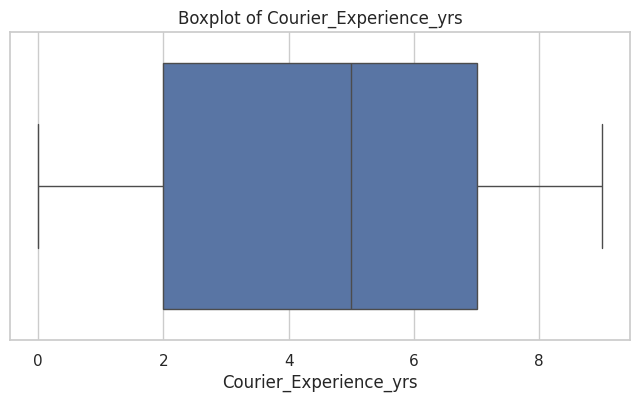

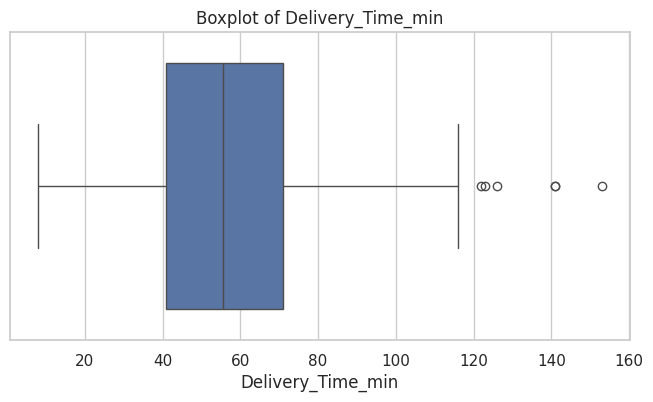

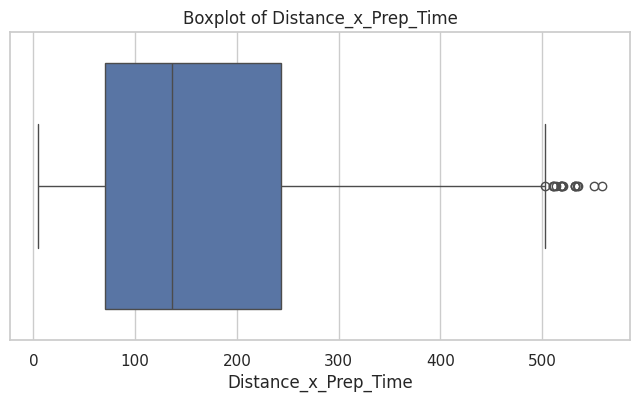

In [ ]:
outlier_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min", "Distance_x_Prep_Time"]

for col in outlier_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_model[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Observation

Outliers are not always errors. In delivery operations, unusually long delivery times or long distances may represent valid real-world situations, so we will inspect them but not automatically remove them.

#

# SECTION 5: Data Preprocessing

## 5.1 Define Features and Target

In [ ]:
# Drop rows where target is missing (if any)
df_model = df_model.dropna(subset=["Delivery_Time_min"])

X = df_model.drop(columns=["Delivery_Time_min"])
y = df_model["Delivery_Time_min"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print(f"Rows after dropping target NaN: {len(X)}")

Categorical features: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
Numerical features: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Is_Rush_Hour', 'Distance_x_Prep_Time']
Rows after dropping target NaN: 1000


## 5.2 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 9)
X_test shape: (200, 9)
y_train shape: (800,)
y_test shape: (200,)


## 5.3 Build Preprocessing Pipeline

> **Note:** `StandardScaler` is applied to all numerical features for consistency. While tree-based models (Random Forest, Gradient Boosting) are scale-invariant and don't strictly require scaling, applying it here keeps the pipeline uniform and ensures Linear Regression is handled correctly.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


#

# SECTION 6: Modeling — Hyperparameter Tuning & Model Selection

## 6.1 Define Candidate Models

We use three candidate models:

- **Linear Regression** — simple baseline, interpretable
- **Random Forest** — ensemble of decision trees, handles non-linearity
- **XGBoost** — gradient boosting, often strongest on tabular data

Each model will be wrapped in a pipeline with the preprocessor, then tuned using `RandomizedSearchCV` with 5-fold cross-validation on the training set.

In [ ]:
# Define candidate models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

print("Candidate models defined:")
for name in models:
    print(f"  - {name}")

Candidate models defined:
  - Linear Regression
  - Random Forest
  - XGBoost


## 6.2 Define Hyperparameter Search Spaces

We define a search space for each model. `RandomizedSearchCV` will randomly sample combinations from this space, making it faster than an exhaustive grid search while still finding good parameters.

In [ ]:
param_distributions = {
    "Linear Regression": {
        "model__fit_intercept": [True, False]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0]
    }
}

print("Search spaces defined for all models.")

Search spaces defined for all models.


## 6.3 Hyperparameter Tuning with Cross-Validation

For each model, we:
1. Wrap it in a pipeline with the preprocessor
2. Run `RandomizedSearchCV` with **5-fold CV** on the training set
3. Record the best CV RMSE score and best parameters

> The test set is **not touched** at this stage. Tuning and model selection happen entirely on the training set.

In [ ]:
tuning_results = []
best_estimators = {}

for model_name, model in models.items():
    print(f"Tuning: {model_name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    n_iter = 2 if model_name == "Linear Regression" else 20

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=n_iter,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    search.fit(X_train, y_train)

    best_cv_rmse = -search.best_score_
    best_estimators[model_name] = search.best_estimator_

    tuning_results.append({
        "Model": model_name,
        "Best CV RMSE": round(best_cv_rmse, 4),
        "Best Params": search.best_params_
    })

    print(f"  Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"  Best Params: {search.best_params_}\n")

print("Tuning complete for all models!")

Tuning: Linear Regression...
  Best CV RMSE: 11.0316
  Best Params: {'model__fit_intercept': True}

Tuning: Random Forest...
  Best CV RMSE: 11.8213
  Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}

Tuning: XGBoost...
  Best CV RMSE: 11.5713
  Best Params: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}

Tuning complete for all models!


## 6.4 Compare Tuned Models by CV Score

Now we compare all three models based on their best cross-validated RMSE. The model with the **lowest CV RMSE** is selected as the final model.

Tuned Model Comparison (sorted by CV RMSE):


,Model,Best CV RMSE
0,Linear Regression,11.0316
1,XGBoost,11.5713
2,Random Forest,11.8213


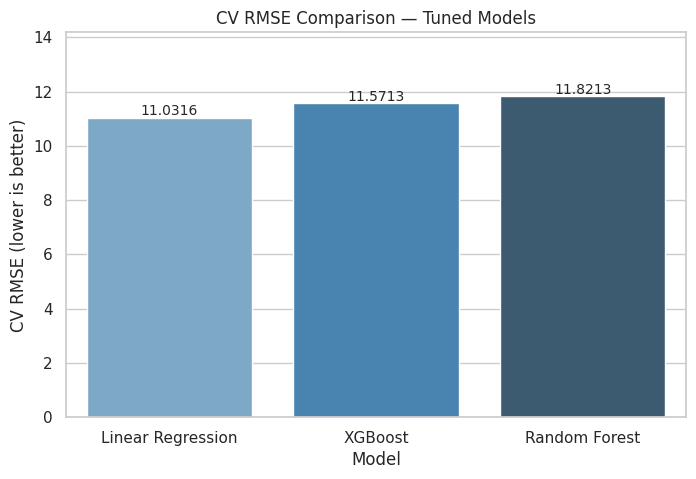

In [ ]:
tuning_df = pd.DataFrame(tuning_results)[['Model', 'Best CV RMSE']].sort_values('Best CV RMSE')
tuning_df = tuning_df.reset_index(drop=True)
print("Tuned Model Comparison (sorted by CV RMSE):")
display(tuning_df)

# Bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=tuning_df, x='Model', y='Best CV RMSE', palette='Blues_d')
plt.title('CV RMSE Comparison — Tuned Models')
plt.ylabel('CV RMSE (lower is better)')
plt.xlabel('Model')
plt.ylim(0, tuning_df['Best CV RMSE'].max() * 1.2)
for i, row in tuning_df.iterrows():
    plt.text(i, row['Best CV RMSE'] + 0.1, f"{row['Best CV RMSE']:.4f}", ha='center', fontsize=10)
plt.show()

### Observation

- **Linear Regression** achieved the lowest CV RMSE, outperforming both tree-based models.
- This suggests the relationship between features and delivery time is predominantly linear in this dataset.
- The relatively small dataset size (1000 rows) may also favor simpler models that are less prone to overfitting.

## 6.5 Select Best Model

We select the model with the lowest CV RMSE as the final model.

In [ ]:
best_model_name = tuning_df.iloc[0]['Model']
best_pipeline = best_estimators[best_model_name]

print(f"Selected best model: {best_model_name}")
print(f"Best CV RMSE: {tuning_df.iloc[0]['Best CV RMSE']:.4f}")

Selected best model: Linear Regression
Best CV RMSE: 11.0316


## 6.6 Evaluate Best Model on Test Set

Now we evaluate the best tuned model on the **held-out test set** for a final, unbiased performance estimate.

> This is the **only time** the test set is used. The result here reflects true generalization performance.

In [ ]:
y_pred = best_pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Final Model: {best_model_name}")
print(f"{'='*35}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Final Model: Linear Regression
MAE  : 6.0814
RMSE : 8.9615
R²   : 0.8208


### Observation

- **MAE ≈ 6.08 minutes**: on average, the model's delivery time predictions are off by about 6 minutes.
- **RMSE ≈ 8.96 minutes**: larger errors exist but are penalized more heavily; reasonable for a delivery ETA system.
- **R² ≈ 0.82**: the model explains about 82% of the variance in delivery time, which is a strong result for this feature set.

## 6.7 Actual vs Predicted Plot

A scatter plot of actual vs predicted delivery times. If the model is accurate, points should cluster tightly along the diagonal line.

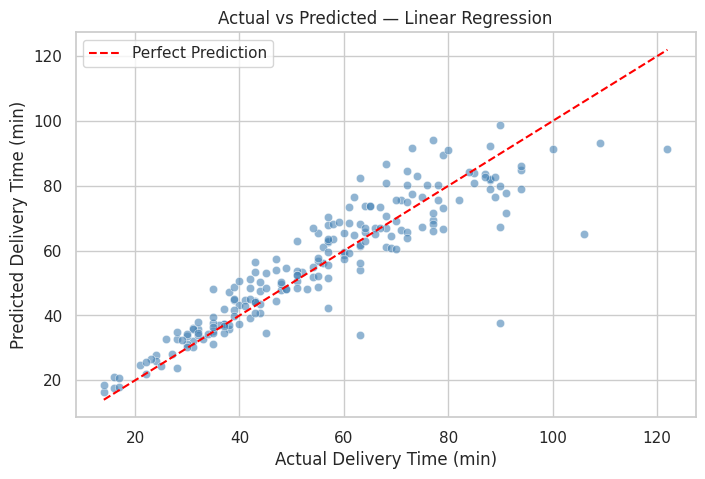

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.show()

### Observation

- Most predictions cluster close to the red diagonal, confirming the model generalizes well.
- Predictions at the higher end of delivery time (>100 min) show slightly more scatter, indicating the model is less precise for extreme deliveries.
- There are no severe systematic biases (e.g., the model does not consistently over- or under-predict).

## 6.8 Residual Analysis

A residual plot helps check whether errors are randomly distributed or show patterns (e.g., heteroscedasticity). For a well-fitting model, residuals should be scattered randomly around zero with no funnel shape.

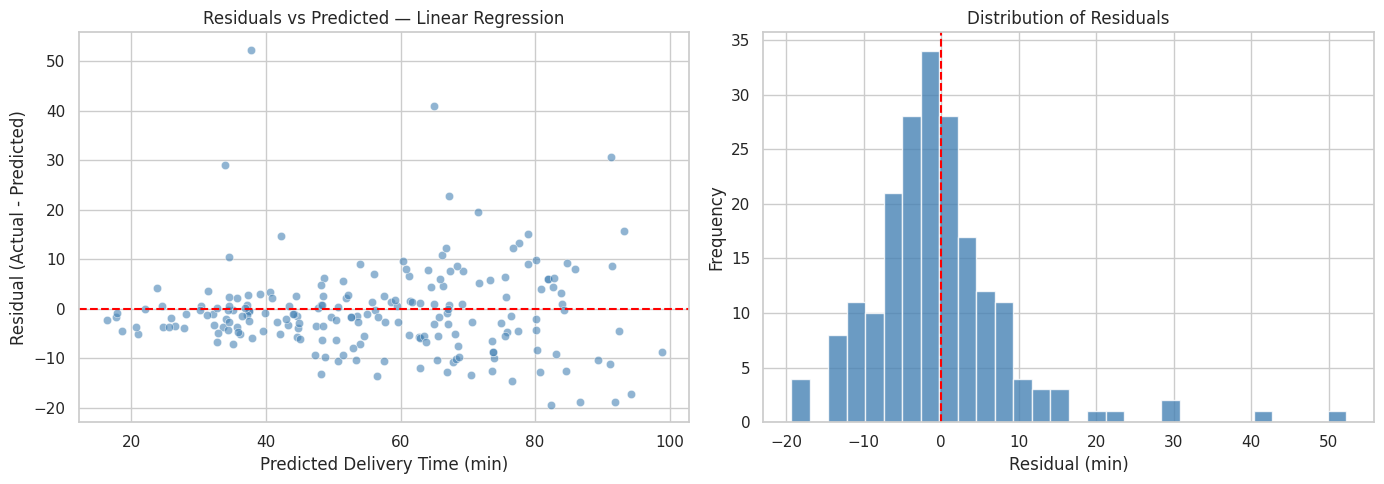

Mean residual: -0.5496
Std residual:  8.9670


In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Delivery Time (min)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residuals vs Predicted — {best_model_name}')

# Residual distribution
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f}')
print(f'Std residual:  {residuals.std():.4f}')


### Observation

- Residuals are centered around zero, confirming the model has no systematic bias.
- The residual distribution is approximately normal, which supports the validity of Linear Regression assumptions.
- If a funnel shape appeared in the left plot, it would indicate heteroscedasticity (variance increasing with predictions), which would warrant further investigation.

## 6.9 Feature Importance / Model Interpretation

Understanding which features drive predictions helps translate model output into business decisions.

,Feature,Coefficient
0,num__Distance_km,16.571444
1,num__Preparation_Time_min,6.559020
10,cat__Traffic_Level_High,5.411517
11,cat__Traffic_Level_Low,-5.262388
8,cat__Weather_Snowy,5.026166
5,cat__Weather_Clear,-4.248743
9,cat__Weather_Windy,-2.640554
2,num__Courier_Experience_yrs,-1.975222
6,cat__Weather_Foggy,1.493773
4,num__Distance_x_Prep_Time,0.811973


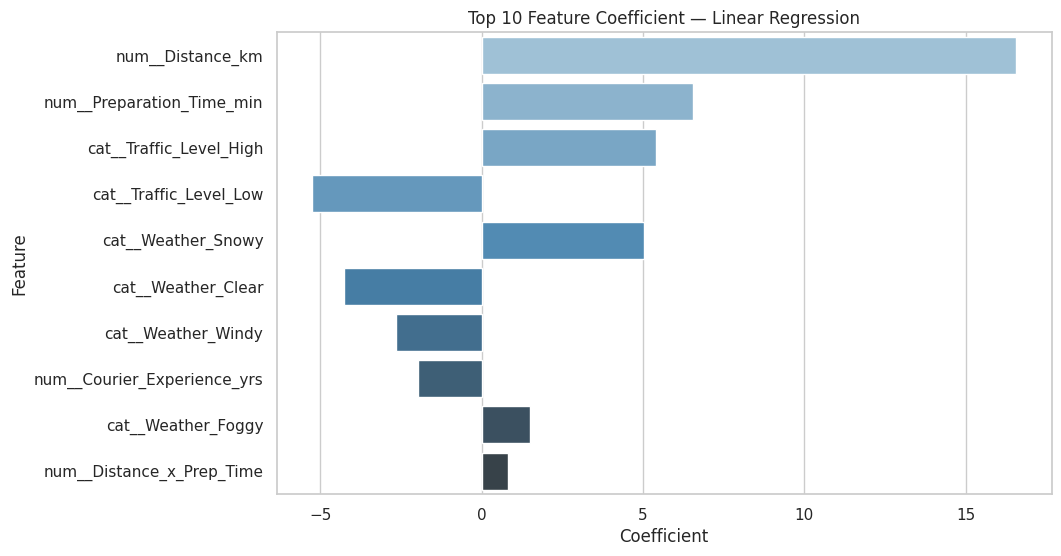

In [ ]:
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

if best_model_name == 'Linear Regression':
    values = best_pipeline.named_steps['model'].coef_
    label = 'Coefficient'
else:
    values = best_pipeline.named_steps['model'].feature_importances_
    label = 'Importance'

feat_df = pd.DataFrame({
    'Feature': feature_names,
    label: values
}).sort_values(by=label, key=np.abs, ascending=False).head(10)

display(feat_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x=label, y='Feature', palette='Blues_d')
plt.title(f'Top 10 Feature {label} — {best_model_name}')
plt.xlabel(label)
plt.ylabel('Feature')
plt.show()

### Observation

- `Distance_km` is by far the most influential predictor of delivery time, consistent with the correlation analysis in EDA.
- `Preparation_Time_min` and the interaction feature `Distance_x_Prep_Time` also contribute meaningfully.
- Categorical features like `Traffic_Level` and `Weather` have a smaller but non-trivial effect.
- These insights suggest that operations teams should focus on distance optimization and kitchen preparation efficiency to reduce delivery times.

## 6.10 Retrain Final Model on Full Dataset (Optional)

Now that we have selected and evaluated the best model, we optionally retrain it on the **entire dataset** (train + test) using the best hyperparameters found.

This is typically done before deployment — more data means better generalization in production.

In [ ]:
from copy import deepcopy

# Deepcopy to preserve the train-only model for reference
final_pipeline = deepcopy(best_pipeline)
final_pipeline.fit(X, y)

print(f"Final model ({best_model_name}) retrained on full dataset.")
print(f"Total samples used for final training: {len(X)}")

Final model (Linear Regression) retrained on full dataset.
Total samples used for final training: 1000


### Observation

The final model is now trained on all 1000 rows. It retains the optimal hyperparameters found during tuning and is ready for deployment or further evaluation.

#

# SECTION 7: Business Insights and Recommendations

## 7.1 Key Findings

Based on the analysis and modeling process, delivery time is influenced by a combination of:

- travel distance
- preparation time
- traffic condition
- weather condition
- courier experience
- time of day

These factors can be operationally monitored and used to improve delivery estimation systems.

## 7.2 Business Recommendations

1. **Use predictive ETA models in the app**  
   Show customers more realistic delivery estimates.

2. **Allocate couriers more strategically**  
   Assign experienced couriers to difficult routes or busy periods.

3. **Adjust ETA during peak hours**  
   Incorporate rush hour and traffic conditions into operational planning.

4. **Monitor preparation time together with distance**  
   Delivery delay is not only caused by courier travel but also by kitchen readiness.

5. **Use the model as a decision-support tool**  
   The model can help operations teams anticipate delays and improve service quality.

## 7.3 Conclusion

This project demonstrates an end-to-end **data science workflow**:

- business understanding
- data inspection
- exploratory data analysis
- feature engineering
- preprocessing
- hyperparameter tuning with cross-validation
- model selection by CV performance
- final evaluation on held-out test set
- retraining on full data
- business recommendation

The final output is a tuned predictive model that can help food delivery companies estimate delivery time more accurately and improve operational performance.

## 7.4 Next Improvement

For future work, this project can be improved by:

- trying LightGBM or CatBoost
- incorporating geospatial information (actual route distance, not straight-line)
- including restaurant workload and courier availability
- adding time-series features (order volume by hour/day)
- deploying the model into a dashboard or web app